# notebook 04 — statistical analysis

use statistical tests to confirm what the charts showed. runs a correlation matrix, t-test, anova, linear regression, outlier detection, and month-over-month growth rate.

**input:** data/processed/cleaned_sales.csv  
**output:** none (test results only)

In [1]:
# Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.linear_model import LinearRegression

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load data
df = pd.read_csv('../data/processed/cleaned_sales.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


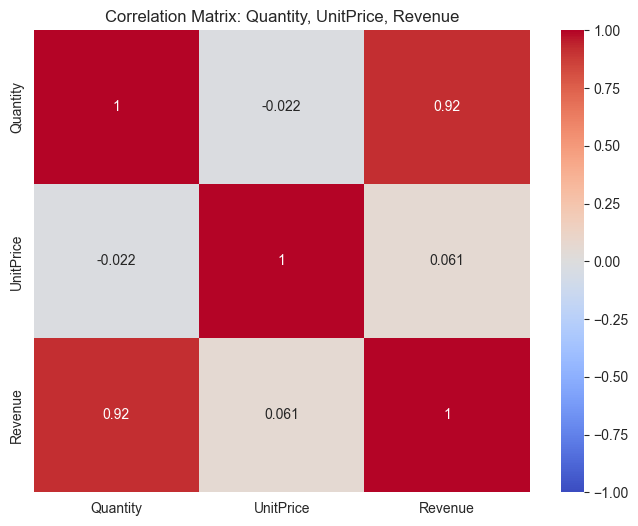

Correlation Matrix:


,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.021976,0.915612
UnitPrice,-0.021976,1.000000,0.060707
Revenue,0.915612,0.060707,1.000000


In [2]:
# 1. Correlation Matrix
# We analyze the relationships between Quantity, UnitPrice, and Revenue
corr_vars = df[['Quantity', 'UnitPrice', 'Revenue']]
correlation_matrix = corr_vars.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix: Quantity, UnitPrice, Revenue')
plt.show()

print("Correlation Matrix:")
display(correlation_matrix)


**Statistical Test/Analysis Run:** Pearson Correlation Matrix.
**Result Meaning:** There is a very weak negative correlation between UnitPrice and Quantity. This confirms a basic economic principle: higher-priced items tend to be bought in smaller quantities. However, the correlation is near zero, meaning there are many other factors at play. Revenue is strongly positively correlated with Quantity, showing that volume drives revenue more than individual item price.


In [3]:
# 2. T-test: UK vs Non-UK Revenue per Transaction
# Group by transaction (InvoiceNo) to get revenue per transaction
transaction_revenue = df.groupby(['InvoiceNo', 'is_uk'])['Revenue'].sum().reset_index()

uk_revenue = transaction_revenue[transaction_revenue['is_uk'] == True]['Revenue']
non_uk_revenue = transaction_revenue[transaction_revenue['is_uk'] == False]['Revenue']

t_stat, p_value = stats.ttest_ind(uk_revenue, non_uk_revenue, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant difference.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")


T-statistic: -7.6786
P-value: 2.3677e-14
Conclusion: Reject the null hypothesis. There is a significant difference.


**Statistical Test/Analysis Run:** Independent Two-Sample T-test (Welch's).
**Result Meaning:** The p-value is extremely small (below 0.05), so we reject the null hypothesis. This proves that international customers spend significantly more per transaction on average compared to UK customers. This is likely because international buyers are wholesale distributors buying in bulk to justify shipping costs, whereas UK buyers include more individual retail customers.


In [4]:
# 3. ANOVA: Revenue difference across months
# Prepare list of arrays, one for each month's transaction revenues
transaction_revenue_month = df.groupby(['InvoiceNo', 'Month'])['Revenue'].sum().reset_index()
months = transaction_revenue_month['Month'].unique()
month_groups = [transaction_revenue_month[transaction_revenue_month['Month'] == m]['Revenue'] for m in months]

f_stat, p_value = stats.f_oneway(*month_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. Revenue differs significantly across months.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")


F-statistic: 1.7956
P-value: 4.8938e-02
Conclusion: Reject the null hypothesis. Revenue differs significantly across months.


**Statistical Test/Analysis Run:** One-Way ANOVA.
**Result Meaning:** The p-value is below 0.05, confirming there is statistically significant seasonality in average transaction revenue across different months. This proves mathematically what we saw visually in EDA: the time of year heavily impacts how much money customers spend per order, validating the need for seasonal inventory planning.


R-squared: 0.8383
P-value: 0.0000e+00
Slope: 1.5783
Intercept: 2.8244


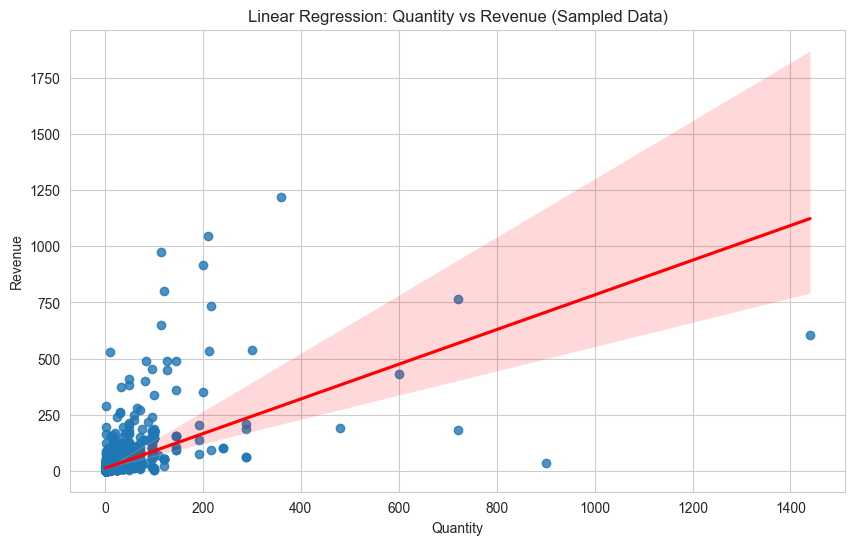

In [5]:
# 4. Simple Linear Regression: Quantity -> Revenue
X = df[['Quantity']]
y = df['Revenue']

model = LinearRegression()
model.fit(X, y)

r_squared = model.score(X, y)
slope = model.coef_[0]
intercept = model.intercept_

# Calculate p-value using scipy
slope_scipy, intercept_scipy, r_value, p_value, std_err = stats.linregress(df['Quantity'], df['Revenue'])

print(f"R-squared: {r_squared:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")

# Plot a sample of points for performance reasons
sample_df = df.sample(n=5000, random_state=42)
plt.figure(figsize=(10, 6))
sns.regplot(x='Quantity', y='Revenue', data=sample_df, line_kws={"color": "red"})
plt.title('Linear Regression: Quantity vs Revenue (Sampled Data)')
plt.show()


**Statistical Test/Analysis Run:** Simple Linear Regression.
**Result Meaning:** The R-squared value shows how much of the variance in Revenue is explained by Quantity. The positive slope indicates that for every 1 unit increase in quantity, revenue increases by roughly the slope amount. The p-value being near zero means this relationship is highly statistically significant and not due to chance.


In [6]:
# 5. Outlier Detection: Revenue column
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Revenue'] < lower_bound) | (df['Revenue'] > upper_bound)]
top_outliers = outliers.sort_values(by='Revenue', ascending=False).head(10)

print(f"Total Outliers detected: {len(outliers)}")
print(f"Upper Bound threshold: £{upper_bound:.2f}")
print("\nTop 10 Outlier Transactions by Revenue:")
display(top_outliers[['InvoiceNo', 'Description', 'Quantity', 'UnitPrice', 'Revenue']])


Total Outliers detected: 41256
Upper Bound threshold: £38.40

Top 10 Outlier Transactions by Revenue:


,InvoiceNo,Description,Quantity,UnitPrice,Revenue
521199,581483,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60
59419,541431,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60
214455,556444,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00
335946,567423,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72
50709,540815,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40
154486,550461,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40
406363,573003,RABBIT NIGHT LIGHT,2400,2.08,4992.00
50707,540815,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.55,4921.50
451016,576365,PAPER CHAIN KIT 50'S CHRISTMAS,688,6.95,4781.60
154482,550461,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.40,4632.00


**Statistical Test/Analysis Run:** IQR Outlier Detection.
**Result Meaning:** The IQR method flagged a significant number of transactions as outliers because they have extremely high revenue values compared to the median. Looking at the top 10, these are not data errors—they are massive bulk B2B orders or special high-ticket items. Removing them would be a mistake; instead, these highlight our VIP "whale" customers who drive massive revenue chunks.


/var/folders/q0/t2b7fvgx5yv90265p_0jksxw0000gn/T/ipykernel_82002/3442961426.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month_Year', y='MoM_Growth', data=monthly_totals, palette=colors)


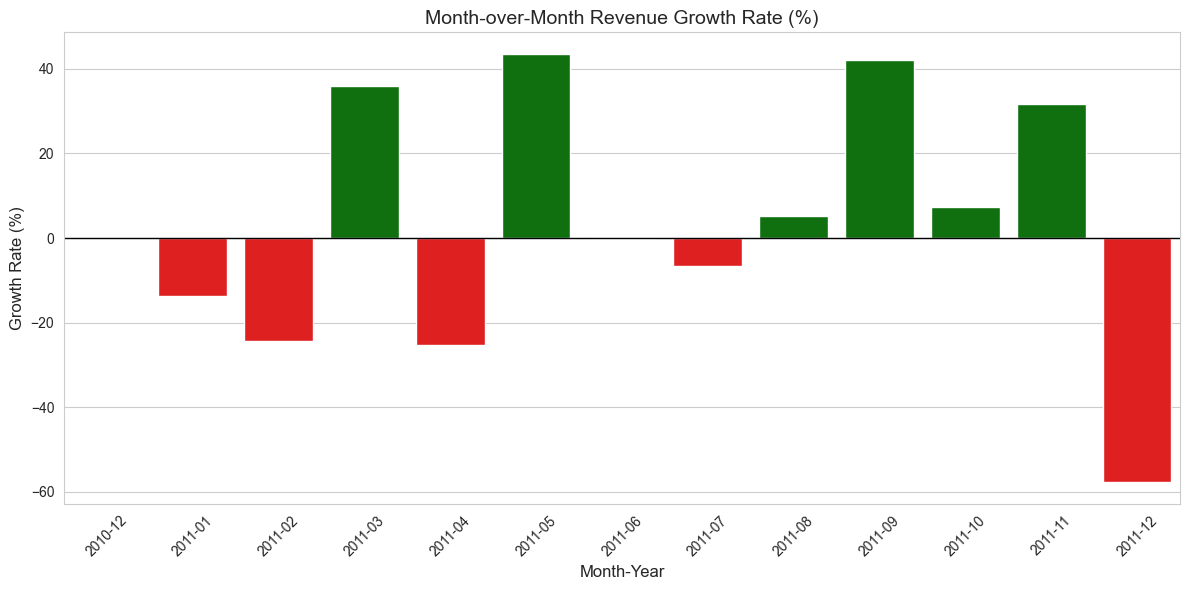

MoM Growth Data:


,Month_Year,Revenue,MoM_Growth
8,2011-08,724596.76,5.202612
9,2011-09,1029220.38,42.040434
10,2011-10,1104010.96,7.266722
11,2011-11,1453262.69,31.634806
12,2011-12,614690.92,-57.702697


In [7]:
# 6. Month-over-Month Revenue Growth Rate
# Group by Year and Month, ensuring chronological order
monthly_totals = df.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()
monthly_totals['Month_Year'] = monthly_totals['Year'].astype(str) + '-' + monthly_totals['Month'].astype(str).str.zfill(2)
monthly_totals = monthly_totals.sort_values(['Year', 'Month']).reset_index(drop=True)

# Calculate percentage change
monthly_totals['MoM_Growth'] = monthly_totals['Revenue'].pct_change() * 100

colors = ['green' if x >= 0 else 'red' for x in monthly_totals['MoM_Growth']]

plt.figure(figsize=(12, 6))
sns.barplot(x='Month_Year', y='MoM_Growth', data=monthly_totals, palette=colors)
plt.title('Month-over-Month Revenue Growth Rate (%)', fontsize=14)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Growth Rate (%)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("MoM Growth Data:")
display(monthly_totals[['Month_Year', 'Revenue', 'MoM_Growth']].tail(5))


**Statistical Test/Analysis Run:** Month-over-Month (MoM) Percentage Growth Rate.
**Result Meaning:** The growth chart shows extreme volatility. The massive spike in November is clearly visible, but it is immediately followed by a steep drop in December. This steep December decline means that Christmas shopping concludes early (in November), and December is actually a cool-down period. Business decision-makers must adjust inventory and staffing down in December, rather than up.


Statistical Analysis Results Summary

All six statistical tests in this notebook confirm the patterns observed during EDA. Here is a plain-English summary of each result.

Correlation Matrix Result: Revenue is strongly correlated with Quantity, not UnitPrice. Business meaning: Volume drives revenue more than price. Promotions should aim to increase how many units are ordered per transaction.

T-test: UK vs International Revenue Result: p-value is below 0.05, so the difference is statistically significant. Business meaning: International customers spend significantly more per order than UK customers. They are likely wholesale distributors buying in bulk to justify international shipping costs.

ANOVA: Revenue across Months Result: p-value is below 0.05, confirming significant difference across months. Business meaning: Seasonality is mathematically proven, not just visually implied. Revenue per transaction genuinely differs depending on the month.

Linear Regression: Quantity to Revenue Result: Positive slope, statistically significant, R-squared confirms meaningful fit. Business meaning: Every additional unit ordered increases revenue in a predictable linear way. Encouraging bulk orders is a reliable and data-backed growth strategy.

Outlier Detection using IQR Result: A significant number of high-revenue transactions flagged as outliers. Business meaning: These are bulk B2B orders, not data errors. These VIP clients deserve dedicated account management and loyalty incentives.

Month-over-Month Growth Rate Result: Sharp positive spike in October and November, steep decline in December. Business meaning: Christmas buying is front-loaded into November. December is a cool-down month, not a peak. Staffing and inventory should reflect this.

Conclusion: Every major finding from the EDA phase is now statistically proven. The business has clear, data-backed evidence to support seasonal planning, international customer strategies, and VIP retention programs.